# Convolutional Neural Networks & the Image Data Pipeline
## LeNet, AlexNet and a real detection dataset: Chinchero textile iconography

**Hands-on lab — approximately 120 minutes · Lab 4 of the series · PyTorch**

Labs 1–3 used NumPy on tabular data. Today you move to **images** and **PyTorch**, on a
real research dataset: photographs of hand-woven textiles from Chinchero (Peru), where
every traditional motif has been annotated with a bounding box — a genuine **object
detection** dataset (CC BY 4.0). In this lab you build the complete *data side* of a
computer-vision project and two classic CNNs. The *detection head* itself is Lab 5.

**What you will do**

| # | Section | Time |
|---|---------|------|
| 1 | The dataset: woven iconography of Chinchero | 8 min |
| 2 | EDA for a detection dataset | 20 min |
| 3 | A Dataset for detection — and why the default DataLoader breaks | 15 min |
| 4 | From detection to classification: building the crop bank | 10 min |
| 5 | Classification Dataset, transforms & augmentation | 18 min |
| 6 | LeNet — reference implementation, explained line by line | 15 min |
| 7 | AlexNet — your turn | 22 min |
| 8 | Saving the model and running inference | 8 min |
| 9 | Wrap-up and homework | — |

**Prerequisites:** Labs 1–3 (gradient descent, train/val/test discipline, overfitting).
The training loop here is the same idea as Lab 1's — PyTorch just automates the
gradients.

**Environment:** designed for Google Colab with a GPU (`Runtime → Change runtime type
→ T4 GPU`), but everything also runs on CPU with reduced settings (auto-detected).

**How to work through this notebook**

- Run every cell in order. Cells marked **`TODO`** are yours; each has a check cell
  and a hidden hint.


> **STUDENT VERSION** — complete the cells marked `TODO 1`–`TODO 6`. Each is followed by a check cell; a hint is hidden below each TODO. All other cells are ready to run.

## 0. Setup

In [5]:
import os, time, random, pickle, ast, re
from collections import Counter
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
FAST_MODE = DEVICE == "cpu"          # smaller settings so CPU-only machines still work
print(f"torch {torch.__version__} | device: {DEVICE} | FAST_MODE: {FAST_MODE}")

# Same colorblind-safe palette as Labs 1-3.
C = {"blue": "#2a78d6", "orange": "#eb6834", "aqua": "#1baf7a",
     "yellow": "#eda100", "red": "#e34948", "ink": "#0b0b0b",
     "muted": "#898781", "grid": "#e1e0d9"}
plt.rcParams.update({
    "figure.figsize": (9, 4.5), "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": C["grid"], "grid.linewidth": 0.8,
    "axes.edgecolor": "#c3c2b7", "font.size": 10.5, "axes.titlesize": 12})

torch 2.11.0+cpu | device: cpu | FAST_MODE: True


In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ---- Locate the dataset -------------------------------------------------------
# On Colab: upload/mount the dataset folder and make sure one of these paths matches.
# The folder must contain classes_name.yaml and (possibly nested) images/ + labels/.
# from google.colab import drive; drive.mount('/content/drive')   # <- uncomment on Colab

CANDIDATE_ROOTS = [ # danh sách đường dẫn dự phòng mà tệp dữ liệu có thể đang lưu trữ
    "/content/drive/MyDrive/Iconography_Chinchero",
    "/content/Iconography_Chinchero",
    "./Iconography_Chinchero",
    "./data_sample",
]
DATA_ROOT = next((Path(p) for p in CANDIDATE_ROOTS
                  if (Path(p) / "classes_name.yaml").exists()), None)
'''
DATA_ROOT lấy 1 đường dẫn chính thức chọn ra từ CANDIDATE_ROOTS
hàm next(..., None): lấy kết quả đầu tiên hợp lệ, trong th ko có thì trả về None
Trong đoạn code này thì nó lấy các đường dẫn có chứa classes_name.yaml

'''
assert DATA_ROOT is not None, ("Dataset not found - edit CANDIDATE_ROOTS to point at "
                               "the folder that contains classes_name.yaml")

IMG_DIR = next(p for p in DATA_ROOT.rglob("images") if p.is_dir())
LBL_DIR = next(p for p in DATA_ROOT.rglob("labels") if p.is_dir())

'''
IMG_DIR, LBL_DIR tìm đường dẫn đến 2 folder images và labels
phương thức rglob basically tìm bất kì tệp hoặc thư mục nào tên images hoặc labels
is_dir() đảm bảo đối tượng tìm đc là thư mục chứ ko phải tệp tin trùng tên
'''

# class names from the YAML (a plain-text parse - no extra dependency needed)
yaml_text = (DATA_ROOT / "classes_name.yaml").read_text() # đọc file classes_name.yaml bằng string
CLASS_NAMES = ast.literal_eval(re.search(r"names:\s*(\[.*\])", yaml_text).group(1))
NUM_CLASSES_TOTAL = len(CLASS_NAMES)

image_paths = sorted(IMG_DIR.glob("*.jpg")) # tìm tất cả các file có dạng .jpg và sort, image_paths lưu các đường dẫn của file
print(f"root: {DATA_ROOT}")
print(f"{len(image_paths)} images | {NUM_CLASSES_TOTAL} motif classes")
print("first five classes:", CLASS_NAMES[:5])

root: /content/drive/MyDrive/Iconography_Chinchero
1358 images | 28 motif classes
first five classes: ['AysaCuty', 'Chaska', 'ChiliChili', 'ChiniPuito', 'ChunchuLoraypu']


## 1. The dataset: woven iconography of Chinchero  *(~8 min)*

Weavers in Chinchero (Cusco region, Peru) encode meaning in their textiles through
traditional motifs — *Chaska* (star), *Loraypu*, *MakiMaki*, *Llama*, and two dozen
more. Digitally preserving this iconography is a real research problem, and this
dataset was built for it: high-resolution photographs (4896×3672) of woven pieces, with
**every motif occurrence annotated by a bounding box** and one of **28 classes**.

**Label format (YOLO convention)** — for image `X.jpg` there is a text file `X.txt`;
each line is one object:

```
class_id  center_x  center_y  width  height
```

with all four geometry numbers **normalized to [0, 1]** (fractions of the image size).
This format is an industry standard — learn to read it once and you can use thousands
of public datasets.

**Two tasks, one dataset.** With box labels you can pose two problems:

- **Classification** (this lab): given a cropped motif, which of the 28 classes is it?
  → LeNet, AlexNet.
- **Detection** (Lab 5): given the whole photograph, find *where* every motif is *and*
  what it is.

We start by understanding the data — never skip this step (Lab 1's lesson, now with
pixels).

## 2. EDA for a detection dataset  *(~20 min)*

### 2.1 Parse the labels

First tool of the day: converting a YOLO line into pixel corner coordinates
`(x1, y1, x2, y2)` — needed for drawing, cropping, and (in Lab 5) IoU. The math is two
lines: the box center is at `(cx·W, cy·H)` and the box extends half its width/height
to each side.

In [ ]:
def parse_yolo_file(path):
    '''Read one YOLO label file -> list of (class_id, cx, cy, w, h), all normalized.
    An empty (or missing) file simply yields an empty list - some photos have no
    annotated motifs, and real datasets ALWAYS contain such surprises.'''
    path = Path(path)
    if not path.exists():
        return []
    rows = []
    for line in path.read_text().strip().splitlines(): # line là các dòng trong file.txt
        parts = line.split() # parts là list 5 con số trên mỗi dòng
        if len(parts) >= 5:
            rows.append((int(parts[0]), *map(float, parts[1:5]))) # nếu có đủ 5 con số thì thêm vào rows 1 tuple chứa 5 con số đó
    return rows

labels_per_image = {p.stem: parse_yolo_file(LBL_DIR / (p.stem + ".txt"))
                    for p in image_paths}
# dictionary comprehension: p.stem là key lấy tên file (ko có .jpg), vế value là list các tuple 5 con số
n_boxes = sum(len(v) for v in labels_per_image.values()) # tính số boxes
print(f"parsed {n_boxes:,} boxes across {len(image_paths)} images")
print("example line (class, cx, cy, w, h):", labels_per_image[image_paths[0].stem][0])

In [7]:
def yolo_to_xyxy(cx, cy, w, h, W, H):
    '''
    Convert one YOLO box (normalized center-format) to pixel corner-format.

    Args:
        cx, cy, w, h (float): YOLO values in [0, 1]
        W, H (int): image width and height in pixels
    Returns:
        (x1, y1, x2, y2) floats in pixels - top-left and bottom-right corners,
        clamped to the image bounds.
    '''
    ### ===== TODO 1 (≈ 4 lines) ================================= ###
    # 1) the box center in pixels is (cx*W, cy*H); it extends w*W/2
    #    to each side horizontally and h*H/2 vertically
    # 2) x1 = (cx - w/2) * W   ... and similarly y1, x2, y2
    # 3) clamp: x1, y1 must be >= 0; x2 <= W; y2 <= H
    x1 = (cx - w/2) * W
    y1 = (cy - h/2) * H
    x2 = (cx + w/2) * W
    y2 = (cy + h/2) * H
    ### ===== END TODO =========================================== ###
    return max(0.0, x1), max(0.0, y1), min(float(W), x2), min(float(H), y2) #clamping


<details><summary><b>Hint — TODO 1</b></summary>

Center format → corner format: `x1 = (cx - w/2) * W`, `x2 = (cx + w/2) * W`,
`y1 = (cy - h/2) * H`, `y2 = (cy + h/2) * H`. The `max`/`min` in the return line
already handles the clamping.
</details>

In [8]:
# ---- Check TODO 1: yolo_to_xyxy -------------------------------------------------
# Hand-checkable case: a box centered in the image, covering half of each dimension,
# in a 400x200 image -> corners (100, 50) to (300, 150).
out = yolo_to_xyxy(0.5, 0.5, 0.5, 0.5, 400, 200)
print("your output:", out)
print("expected:   (100.0, 50.0, 300.0, 150.0)")
assert out is not None and None not in out, "returned None - did you complete the TODO?"
assert np.allclose(out, (100.0, 50.0, 300.0, 150.0)), "wrong corners - check the formulas"
# a box hanging over the left edge must be clamped to 0:
out2 = yolo_to_xyxy(0.05, 0.5, 0.2, 0.2, 400, 200)
assert out2[0] == 0.0, "x1 should be clamped to 0 for boxes touching the edge"
print("PASSED: yolo_to_xyxy is correct")

your output: (100.0, 50.0, 300.0, 150.0)
expected:   (100.0, 50.0, 300.0, 150.0)
PASSED: yolo_to_xyxy is correct


### 2.2 Look at the images — with their boxes

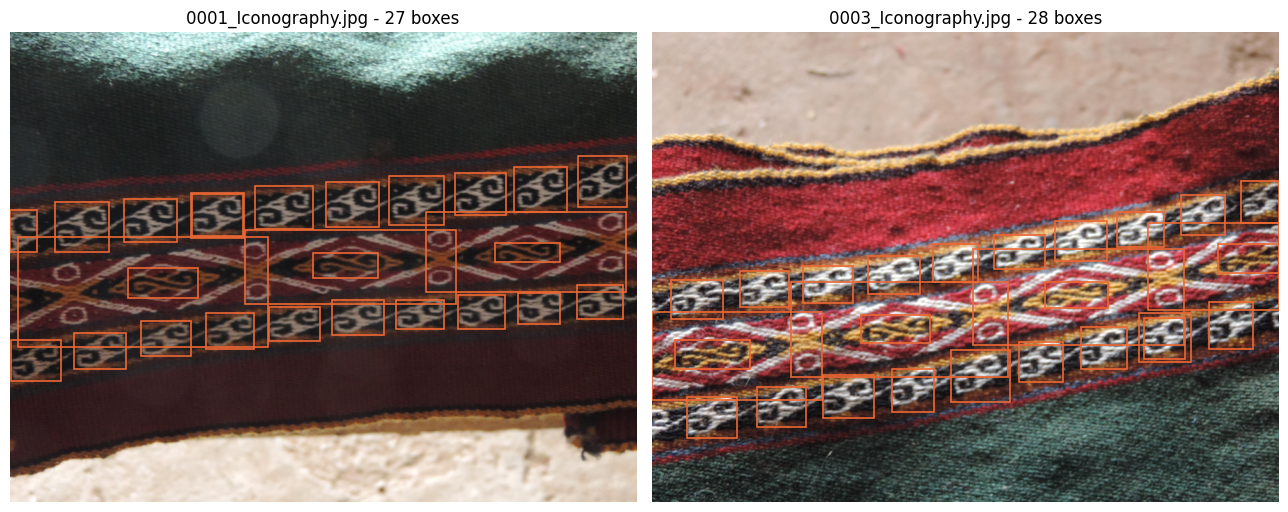

In [9]:
from matplotlib.patches import Rectangle

def show_with_boxes(ax, img_path, max_side=900):
    img = Image.open(img_path).convert("RGB") # mở ảnh xong chuyển đổi sang định dạng RGB
    scale = max_side / max(img.size) # thu nhỏ ảnh để hiển thị mượt hơn
    img_small = img.resize((int(img.width * scale), int(img.height * scale)))
    ax.imshow(img_small)
    rows = labels_per_image[img_path.stem] # rows là n tuple 5 con số (trong đó n là số boxes)
    for c, cx, cy, w, h in rows:
        x1, y1, x2, y2 = yolo_to_xyxy(cx, cy, w, h, img_small.width, img_small.height)
        ax.add_patch(Rectangle((x1, y1), x2 - x1, y2 - y1,
                               fill=False, edgecolor=C["orange"], linewidth=1.2))
    ax.set(title=f"{img_path.name} - {len(rows)} boxes")
    ax.axis("off")

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
show_with_boxes(axes[0], image_paths[0])
show_with_boxes(axes[1], image_paths[2])
plt.tight_layout(); plt.show() # vẽ hình ra

**Take a moment with this picture.** Motifs are *small*, *repeated*, and *densely
packed* — a woven band contains the same pattern over and over. This is nothing like
the toy detection datasets used in textbooks (one banana in the middle of an image);
it is what real annotation projects look like.

### 2.3 Quantify it: three distributions every detection project must know

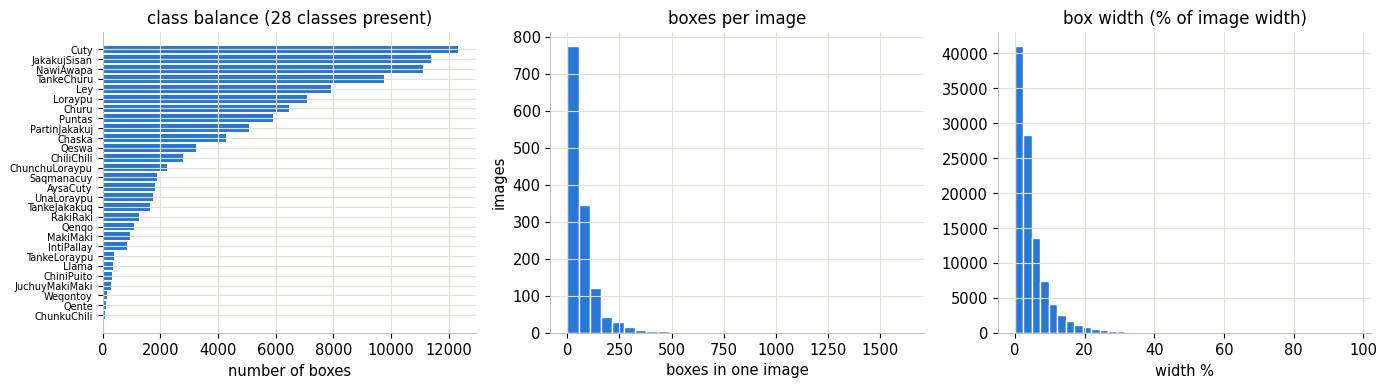

boxes per image - min 0, median 48, max 1626
box width - median 3.1% of image width (~152px at full resolution)
images with ZERO boxes: 4
rarest classes: [('JuchuyMakiMaki', 298), ('Weqontoy', 149), ('Qente', 103), ('ChunkuChili', 99)]


In [10]:
all_rows = [r for v in labels_per_image.values() for r in v]
cls_counts = Counter(r[0] for r in all_rows)
boxes_per_img = [len(v) for v in labels_per_image.values()]
box_w = np.array([r[3] for r in all_rows])   # normalized widths
box_h = np.array([r[4] for r in all_rows])

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

order = [c for c, _ in cls_counts.most_common()]
axes[0].barh([CLASS_NAMES[c] for c in order[::-1]],
             [cls_counts[c] for c in order[::-1]], color=C["blue"])
axes[0].set(title=f"class balance ({len(cls_counts)} classes present)",
            xlabel="number of boxes")
axes[0].tick_params(axis="y", labelsize=7)

axes[1].hist(boxes_per_img, bins=30, color=C["blue"], edgecolor="white")
axes[1].set(title="boxes per image", xlabel="boxes in one image", ylabel="images")

axes[2].hist(box_w * 100, bins=40, color=C["blue"], edgecolor="white")
axes[2].set(title="box width (% of image width)", xlabel="width %")
plt.tight_layout(); plt.show()

print(f"boxes per image - min {min(boxes_per_img)}, median {int(np.median(boxes_per_img))}, "
      f"max {max(boxes_per_img)}")
print(f"box width - median {np.median(box_w):.1%} of image width "
      f"(~{np.median(box_w)*4896:.0f}px at full resolution)")
print(f"images with ZERO boxes: {sum(1 for b in boxes_per_img if b == 0)}")
print(f"rarest classes: "
      f"{[(CLASS_NAMES[c], n) for c, n in cls_counts.most_common()[-4:]]}")

**EDA takeaways** (each one will drive a design decision):

1. **Severe class imbalance** — the most common motif has hundreds of times more boxes
   than the rarest. We must cap samples per class (Section 4) and read per-class
   results, not just overall accuracy (Lab 2's lesson, again).
2. **Dozens of boxes per image, some images with none** — batching such labels is a
   real engineering problem (Section 3), and empty label files must not crash the
   pipeline.
3. **Motifs are small** (median a few % of image width) but the photos are huge
   (4896×3672) — so a *crop* of a motif is still a perfectly usable small image.
   That observation powers this whole lab.

## 3. A Dataset for detection — and why the default DataLoader breaks  *(~15 min)*

### 3.1 The PyTorch data contract

PyTorch separates *what a sample is* from *how samples are batched*:

- A **`Dataset`** answers two questions: `__len__` — how many samples? — and
  `__getitem__(i)` — give me sample *i*. That's the whole contract.
- A **`DataLoader`** wraps a Dataset and handles batching, shuffling, and parallel
  loading (`num_workers` background processes decode images while the GPU trains —
  the difference between a starved GPU and a fed one).

For detection, the community convention (used by torchvision's detection models) is
that a sample is a pair `(image, target)` where `target` is a dict with `"boxes"`
(N×4 tensor, corner format) and `"labels"` (N,). Note that **N differs per image** —
remember the histogram above. Here is a complete detection Dataset (given — read every
line, you will write the classification twin yourself in Section 5):

In [11]:
class ChincheroDetection(Dataset):
    '''One sample = (image_tensor, {"boxes": (N,4) xyxy px, "labels": (N,)}).'''

    def __init__(self, image_paths, resize_to=512):
        self.image_paths = list(image_paths)
        self.resize_to = resize_to

    def __len__(self): # magic method
        return len(self.image_paths)

    def __getitem__(self, idx):
        path = self.image_paths[idx]
        img = Image.open(path).convert("RGB").resize((self.resize_to, self.resize_to))
        W = H = self.resize_to
        rows = parse_yolo_file(LBL_DIR / (path.stem + ".txt"))
        boxes = torch.tensor([yolo_to_xyxy(cx, cy, w, h, W, H)
                              for _, cx, cy, w, h in rows],
                             dtype=torch.float32).reshape(-1, 4)
        labels = torch.tensor([c for c, *_ in rows], dtype=torch.int64)
        return transforms.ToTensor()(img), {"boxes": boxes, "labels": labels}

det_ds = ChincheroDetection(image_paths)
img0, tgt0 = det_ds[0]
print("one sample:", tuple(img0.shape), "| boxes:", tuple(tgt0["boxes"].shape),
      "| labels:", tuple(tgt0["labels"].shape))
img1, tgt1 = det_ds[1]
print("another:   ", tuple(img1.shape), "| boxes:", tuple(tgt1["boxes"].shape),
      "-> a DIFFERENT number of boxes")

one sample: (3, 512, 512) | boxes: (27, 4) | labels: (27,)
another:    (3, 512, 512) | boxes: (22, 4) -> a DIFFERENT number of boxes


### 3.2 Watch the default DataLoader break

The default batching logic calls `torch.stack` on every field of the samples — which
requires *identical shapes*. Images are fine (we resized them all to 512×512). The
boxes are not:

In [12]:
bad_loader = DataLoader(det_ds, batch_size=4)
try:
    next(iter(bad_loader))
    print("no error!?")
except RuntimeError as e:
    print("RuntimeError from the default collate:\n   ", str(e)[:160], "...")

RuntimeError from the default collate:
    stack expects each tensor to be equal size, but got [27, 4] at entry 0 and [22, 4] at entry 1 ...


A `(27, 4)` tensor cannot be stacked with a `(74, 4)` tensor — variable-length
targets simply do not fit into one rectangular batch tensor. The fix is the
`collate_fn` argument: a function that receives the **list of samples** and decides
how to combine them. For detection, the standard answer (used by every torchvision
detection example) is refreshingly humble: *don't stack anything* — return the images
as a tuple and the targets as a tuple.

In [13]:
def detection_collate(batch):
    '''
    batch: list of (image, target) pairs, e.g. [(img0, tgt0), (img1, tgt1), ...]
    Returns: (images, targets) where each is a tuple - images[i] pairs with targets[i].
    '''
    ### ===== TODO 2 (1-2 lines) ================================= ###
    # "Unzip" the list of pairs into two parallel tuples.
    # Python's zip(*batch) does exactly this - think about why!
    images, targets = tuple(zip(*batch))
    ### ===== END TODO =========================================== ###
    return images, targets
'''
Tách images và targets ra làm 2 tuple riêng
Images có cùng kích thước thì có thể gom lại trong một batch cho gpu xử lý, còn targets khác nhau thì xử lý riêng
'''

'\nTách images và targets ra làm 2 tuple riêng\nImages có cùng kích thước thì có thể gom lại trong một batch cho gpu xử lý, còn targets khác nhau thì xử lý riêng\n'

<details><summary><b>Hint — TODO 2</b></summary>

`zip(*batch)` transposes a list of pairs into pairs of lists:
`[(a1,b1),(a2,b2)] → (a1,a2), (b1,b2)`. So `images, targets = tuple(zip(*batch))`
(or simply build two lists with a loop — equally correct).
</details>

In [14]:
# ---- Check TODO 2: detection_collate ---------------------------------------------
good_loader = DataLoader(det_ds, batch_size=4, collate_fn=detection_collate)
images, targets = next(iter(good_loader))
assert images is not None, "detection_collate returned None"
assert len(images) == 4 and len(targets) == 4, "should get 4 images and 4 targets"
assert torch.is_tensor(images[0]) and images[0].shape == (3, 512, 512)
assert all("boxes" in t and "labels" in t for t in targets)
print("PASSED: batch of 4 loaded; boxes per image:",
      [int(t["boxes"].shape[0]) for t in targets])

PASSED: batch of 4 loaded; boxes per image: [27, 22, 28, 65]


### 3.3 Augmentation for detection: the boxes must move with the pixels

One more detection-specific trap before we move on. If you flip an image but not its
boxes, every label is now *wrong* — silently. Modern torchvision (`transforms.v2`)
solves this by making boxes a first-class citizen: wrap them in
`tv_tensors.BoundingBoxes`, and the same transform object moves pixels *and* geometry
together. Run and study (given):

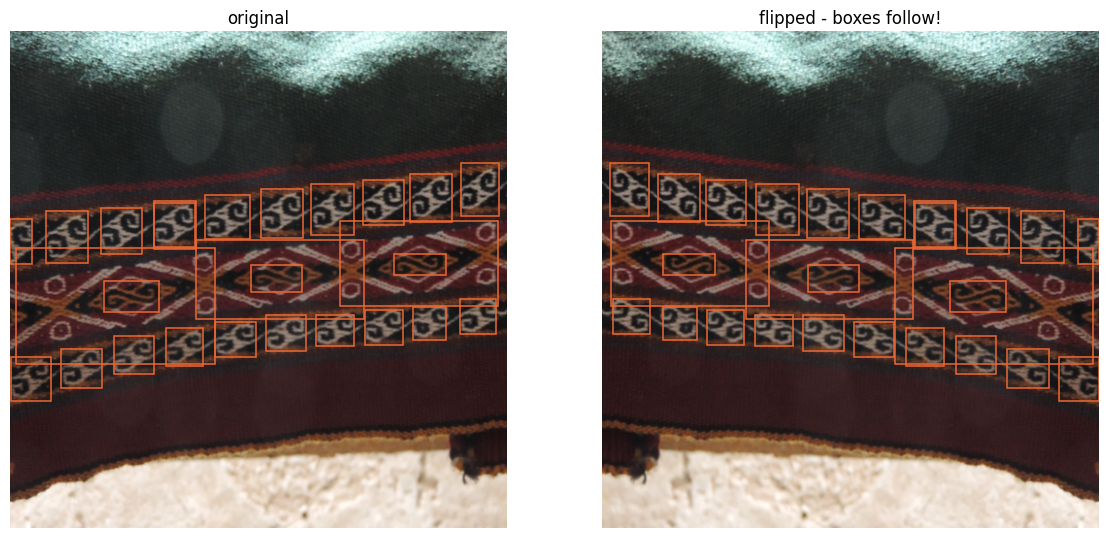

In [15]:
from torchvision import tv_tensors
from torchvision.transforms import v2

img, tgt = det_ds[0] # ảnh và boxes+labels ảnh số 0
boxes_tv = tv_tensors.BoundingBoxes(tgt["boxes"], format="XYXY",
                                    canvas_size=(512, 512))
flip = v2.RandomHorizontalFlip(p=1.0)          # p=1: always flip, for the demo
img_f, boxes_f = flip(img, boxes_tv)

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
for ax, im, bx, ttl in [(axes[0], img, tgt["boxes"], "original"),
                        (axes[1], img_f, boxes_f, "flipped - boxes follow!")]:
    ax.imshow(im.permute(1, 2, 0))
    for x1, y1, x2, y2 in bx.tolist()[:60]:
        ax.add_patch(Rectangle((x1, y1), x2 - x1, y2 - y1,
                               fill=False, edgecolor=C["orange"], lw=1.1))
    ax.set(title=ttl); ax.axis("off")
plt.tight_layout(); plt.show()

This detection pipeline — Dataset contract, custom collate, box-aware transforms —
is exactly what Lab 5 will train on. Park it for now; we take a strategic detour.

## 4. From detection to classification: the crop bank  *(~10 min)*

Before asking a model to find motifs, let's ask a simpler question: **given a motif,
can a CNN even recognize it?** If the answer is no, detection is hopeless anyway; if
yes, the classifier becomes the *backbone* of Lab 5's detector. (This
classification-first strategy is exactly how the field itself progressed — and how
Andrew Ng's course motivates detection via "sliding-window classifiers".)

The boxes give us the training data for free: **crop every annotated motif out of its
photograph** and file it under its class. We cap the number of crops per class — EDA
showed the imbalance — and skip degenerate boxes. (Given code; note where your
`yolo_to_xyxy` does the work.)

In [19]:
CROP_DIR = Path("crops")
MAX_PER_CLASS = 150 if FAST_MODE else 400
MIN_BOX_PX = 24

if not CROP_DIR.exists():
    t0 = time.time()
    counts = Counter()
    for p in image_paths:
        rows = labels_per_image[p.stem]
        if not rows:
            continue
        img = Image.open(p).convert("RGB")
        W, H = img.size
        for k, (c, cx, cy, w, h) in enumerate(rows):
            if counts[c] >= MAX_PER_CLASS:
                continue
            x1, y1, x2, y2 = yolo_to_xyxy(cx, cy, w, h, W, H)   # <- your TODO 1
            if x2 - x1 < MIN_BOX_PX or y2 - y1 < MIN_BOX_PX:
                continue                                         # skip tiny/degenerate
            crop = img.crop((x1, y1, x2, y2))
            crop.thumbnail((256, 256))                           # cap stored size
            out_dir = CROP_DIR / CLASS_NAMES[c]
            out_dir.mkdir(parents=True, exist_ok=True)
            crop.save(out_dir / f"{p.stem}_{k}.jpg", quality=90)
            counts[c] += 1
    print(f"extracted crops in {time.time()-t0:.1f}s")

crop_files = sorted(CROP_DIR.rglob("*.jpg"))
by_class = Counter(f.parent.name for f in crop_files)
print(f"crop bank: {len(crop_files)} crops, {len(by_class)} classes")

# keep classes with enough examples to learn from
MIN_CROPS = 30
kept_classes = sorted([c for c, n in by_class.items() if n >= MIN_CROPS])
class_to_idx = {name: i for i, name in enumerate(kept_classes)}
print(f"kept {len(kept_classes)} classes with >= {MIN_CROPS} crops "
      f"(dropped: {sorted(set(by_class) - set(kept_classes))})")

crop bank: 427 crops, 6 classes
kept 5 classes with >= 30 crops (dropped: ['Qenqo'])


In [20]:
!mkdir /content/drive/MyDrive/Iconography_Chinchero/crops
!cp -r /content/crops /content/drive/MyDrive/Iconography_Chinchero/crops

mkdir: cannot create directory ‘/content/drive/MyDrive/Iconography_Chinchero/crops’: File exists
^C


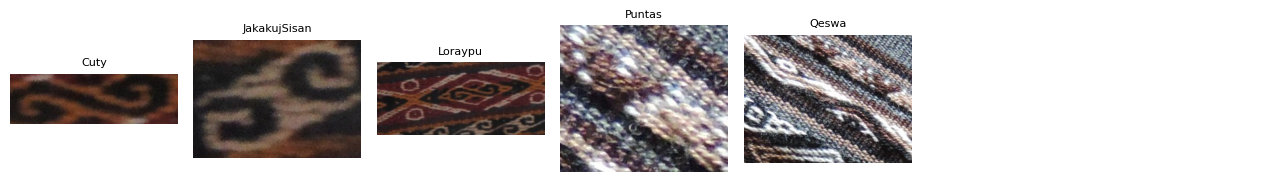

In [21]:
# One crop per kept class - meet your 'students':
n = len(kept_classes)
cols = 7; rows_n = int(np.ceil(n / cols))
fig, axes = plt.subplots(rows_n, cols, figsize=(13, 2 * rows_n))
for ax in axes.flat: ax.axis("off")
for ax, name in zip(axes.flat, kept_classes):
    f = next(f for f in crop_files if f.parent.name == name)
    ax.imshow(Image.open(f)); ax.set_title(name, fontsize=8)
plt.tight_layout(); plt.show()

In [22]:
# Files + integer labels, split 70/15/15 stratified (Lab 2's discipline)
from sklearn.model_selection import train_test_split

files  = [f for f in crop_files if f.parent.name in kept_classes]
labels = [class_to_idx[f.parent.name] for f in files]

train_files, tmp_f, train_labels, tmp_y = train_test_split(
    files, labels, test_size=0.30, random_state=SEED, stratify=labels)
val_files, test_files, val_labels, test_labels = train_test_split(
    tmp_f, tmp_y, test_size=0.50, random_state=SEED, stratify=tmp_y)

NUM_CLASSES = len(kept_classes)
print(f"train {len(train_files)} | val {len(val_files)} | test {len(test_files)} "
      f"| {NUM_CLASSES} classes")

train 298 | val 64 | test 64 | 5 classes


## 5. Classification Dataset, transforms & augmentation  *(~18 min)*

### 5.1 Your Dataset

Time to write the classification twin of Section 3's Dataset. Each sample: load the
crop file, apply the transform pipeline, return `(tensor, label)`.

In [23]:
class MotifDataset(Dataset): # tạo một dataset tùy chỉnh, giúp đọc và tiền xử lý các ảnh crop
    '''Classification dataset over the crop bank: sample = (image_tensor, class_idx).'''

    def __init__(self, files, labels, transform):
        self.files = list(files)
        self.labels = list(labels)
        self.transform = transform

    ### ===== TODO 3 (two methods, ≈ 5 lines total) =============== ###
    # __len__      : number of samples
    # __getitem__  : 1) open self.files[idx] with PIL, .convert("RGB")
    #                   (some JPEGs are grayscale - convert makes them 3-channel)
    #                2) apply self.transform
    #                3) return (transformed_image, self.labels[idx])
    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img = Image.open(self.files[idx]).convert("RGB")
        transformed_image = self.transform(img) # áp dụng các phép biến đổi (resize, augmentation, ...)
        return (transformed_image, self.labels[idx]) # trả về 1 tuple

    ### ===== END TODO ============================================ ###

<details><summary><b>Hint — TODO 3</b></summary>

`__len__`: `return len(self.files)`. `__getitem__`:
`img = Image.open(self.files[idx]).convert("RGB")`, then
`return self.transform(img), self.labels[idx]`.
</details>

### 5.2 Transforms: the image version of Lab 1's scaler

A transform pipeline plays exactly the role z-scoring played in Labs 1–3 — and the
golden rule transfers verbatim:

- **`Resize`** — CNNs need a fixed input size.
- **`ToTensor`** — PIL image → float tensor in [0,1], shape (C, H, W).
- **`Normalize(mean, std)`** — per-channel z-score. The mean/std are *learned from the
  training crops only* (sound familiar?), and they must ship with the model at
  inference time (Section 8 — the scaler pitfall rides again).
- **Augmentation** (train only!): random flips/rotations/color-jitter create label-
  preserving variety, fighting overfitting exactly like Lab 3's regularization —
  it is effectively free extra data. Applying augmentation to validation or test
  would randomize your measurements: eval transforms stay deterministic.

In [24]:
# per-channel mean/std from a sample of TRAINING crops (the golden rule, pixel edition)
probe = transforms.Compose([transforms.Resize((64, 64)), transforms.ToTensor()]) # chuỗi gộp các phép biến đổi lại với nhau để gọi cho tiện thay vì gọi mỗi thằng riêng
stack = torch.stack([probe(Image.open(f).convert("RGB")) for f in train_files[:300]]) # ghép các ảnh Tensor lại thành 1 tensor duy nhất chứa toàn bộ batch
MEAN = stack.mean(dim=(0, 2, 3)).tolist() # list mean của 3 kênh màu RGB
STD  = stack.std(dim=(0, 2, 3)).tolist() # list std của 3 kênh màu RGB
print("train mean:", np.round(MEAN, 3), " train std:", np.round(STD, 3))

train mean: [0.396 0.314 0.302]  train std: [0.252 0.239 0.237]


In [25]:
def make_transforms(img_size):
    '''Return (train_transform, eval_transform) for a given input size.'''
    ### ===== TODO 4 (two Compose pipelines) ====================== ###
    # train_tf: Resize((img_size, img_size))
    #           -> RandomHorizontalFlip(p=0.5)
    #           -> RandomRotation(10)
    #           -> ColorJitter(brightness=0.2, contrast=0.2)
    #           -> ToTensor() -> Normalize(MEAN, STD)
    # eval_tf:  the SAME pipeline WITHOUT the three augmentation steps.
    # (Order matters: augment on the PIL image, ToTensor, then Normalize last.)
    train_tf = transforms.Compose([transforms.Resize((img_size, img_size)), transforms.RandomHorizontalFlip(p=0.5), transforms.RandomRotation(10), transforms.ColorJitter(brightness=0.2, contrast=0.2), transforms.ToTensor(), transforms.Normalize(MEAN, STD)])
    eval_tf = transforms.Compose([transforms.Resize((img_size, img_size)), transforms.ToTensor(), transforms.Normalize(MEAN, STD)])
    ### ===== END TODO ============================================ ###
    return train_tf, eval_tf

<details><summary><b>Hint — TODO 4</b></summary>

`transforms.Compose([...])` chains steps in order. Train:
`[Resize, RandomHorizontalFlip(0.5), RandomRotation(10), ColorJitter(0.2, 0.2),
ToTensor(), Normalize(MEAN, STD)]`. Eval: `[Resize, ToTensor(), Normalize(MEAN, STD)]`
— identical except no randomness. Why no augmentation at eval? You want to measure the
model, not the dice.
</details>

In [26]:
# ---- Check TODO 3 + 4 --------------------------------------------------------------
train_tf32, eval_tf32 = make_transforms(32)
assert train_tf32 is not None and eval_tf32 is not None, "make_transforms returned None"

ds_chk = MotifDataset(train_files, train_labels, eval_tf32)
assert len(ds_chk) == len(train_files), "__len__ wrong"
x, y = ds_chk[0]
assert torch.is_tensor(x) and x.shape == (3, 32, 32), f"bad sample shape {x.shape}"
assert 0 <= y < NUM_CLASSES, "label out of range"

# eval must be deterministic; train must be random
xa, xb = ds_chk[0][0], ds_chk[0][0]
assert torch.allclose(xa, xb), "eval transform should give identical tensors every time"
ds_aug = MotifDataset(train_files, train_labels, train_tf32)
za, zb = ds_aug[0][0], ds_aug[0][0]
assert not torch.allclose(za, zb), ("train transform gave identical tensors twice - "
                                    "did you include the random augmentations?")
print("PASSED: MotifDataset + transforms are correct")

PASSED: MotifDataset + transforms are correct


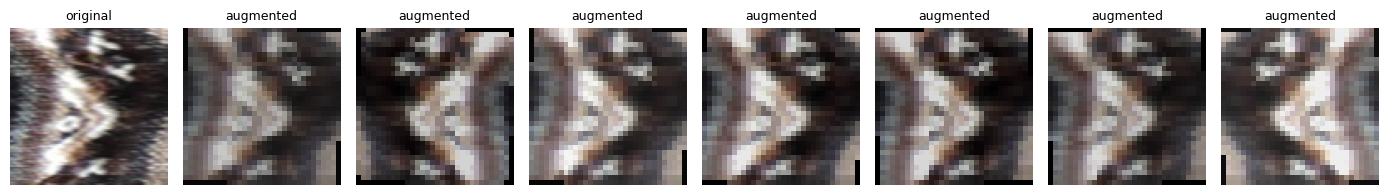

In [27]:
# Augmentation, seen: one crop through the train pipeline eight times
raw = Image.open(train_files[0]).convert("RGB")
fig, axes = plt.subplots(1, 8, figsize=(14, 2.2))
axes[0].imshow(raw.resize((96, 96))); axes[0].set_title("original", fontsize=9)
for ax in axes.flat: ax.axis("off")
show_tf = transforms.Compose(train_tf32.transforms[:-2] + [transforms.ToTensor()])
for ax in axes.flat[1:]:
    ax.imshow(show_tf(raw.resize((96, 96))).permute(1, 2, 0))
    ax.set_title("augmented", fontsize=9)
plt.tight_layout(); plt.show()

In [28]:
BATCH = 64
def make_loaders(img_size, batch=BATCH):
    train_tf, eval_tf = make_transforms(img_size)
    return (
        DataLoader(MotifDataset(train_files, train_labels, train_tf),
                   batch_size=batch, shuffle=True,  num_workers=2),
        DataLoader(MotifDataset(val_files, val_labels, eval_tf),
                   batch_size=batch, shuffle=False, num_workers=2),
        DataLoader(MotifDataset(test_files, test_labels, eval_tf),
                   batch_size=batch, shuffle=False, num_workers=2),
    )

train_loader32, val_loader32, test_loader32 = make_loaders(32)
xb, yb = next(iter(train_loader32))
print("one batch:", tuple(xb.shape), "labels:", tuple(torch.as_tensor(yb).shape))
print("(shuffle=True ONLY for train - eval order must be stable and reproducible)")

one batch: (64, 3, 32, 32) labels: (64,)
(shuffle=True ONLY for train - eval order must be stable and reproducible)


## 6. LeNet — reference implementation  *(~15 min)*

### 6.1 Why convolutions at all?

Imagine feeding a 224×224 RGB image to Lab 1-style fully-connected layers: the first
layer alone, with a modest 1000 units, needs 224·224·3·1000 ≈ **150 million weights** —
and a motif shifted 10 pixels right would look like a completely different input.
Convolutions fix both problems at once: a small filter (say 5×5) slides across the
image, **sharing its weights at every position** — few parameters, and shift-robust by
construction. Output size follows one formula worth memorizing:

$$\text{out} = \left\lfloor \frac{\text{in} - K + 2P}{S} \right\rfloor + 1
\qquad (K \text{ kernel}, P \text{ padding}, S \text{ stride})$$

**LeNet-5** (LeCun et al., 1998 — reading handwritten digits on real US mail!) is the
original demonstration that *stacking* convolution + pooling layers, then flattening
into a small classifier head, works. Below is the standard modern adaptation (ReLU and
max-pool in place of 1998's tanh and average-pool), fully given — study it line by
line, because AlexNet (your turn, next section) is the same idea scaled up.

In [29]:
class LeNet(nn.Module):
    '''LeNet-5, modern flavor: 32x32 RGB in, num_classes logits out.'''

    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential( # trích xuất đặc trưng - feature extractor
            # (3, 32, 32) -> conv 5x5 -> (6, 28, 28)      [ (32-5)/1 + 1 = 28 ]
            nn.Conv2d(in_channels=3, out_channels=6, kernel_size=5),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),                  # -> (6, 14, 14)
            # -> conv 5x5 -> (16, 10, 10)                  [ (14-5)/1 + 1 = 10 ]
            nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),                  # -> (16, 5, 5)
        )
        self.classifier = nn.Sequential( # phần phân loại
            nn.Linear(16 * 5 * 5, 120), nn.ReLU(),
            nn.Linear(120, 84), nn.ReLU(),
            nn.Linear(84, num_classes),                   # logits (no softmax here -
        )                                                 #  CrossEntropyLoss adds it)

    def forward(self, x): # hàm kết hợp 2 cái trên, x là thông tin tensor của batch size bức ảnh (B x C x H x W)
        x = self.features(x)          # convolutional feature extractor
        x = torch.flatten(x, 1)       # (B, 16, 5, 5) -> (B, 400), trải bức ảnh ra thành tensor 1D
        x = self.classifier(x)        # fully-connected head
        return x

lenet = LeNet(NUM_CLASSES).to(DEVICE)
print(lenet)
print("\nparameters:", f"{sum(p.numel() for p in lenet.parameters()):,}")

LeNet(
  (features): Sequential(
    (0): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Linear(in_features=400, out_features=120, bias=True)
    (1): ReLU()
    (2): Linear(in_features=120, out_features=84, bias=True)
    (3): ReLU()
    (4): Linear(in_features=84, out_features=5, bias=True)
  )
)

parameters: 61,581


In [30]:
# Shape trace - watch one tensor flow through the network (THE debugging tool
# for CNNs; use it whenever a size mismatch error appears):
x = torch.zeros(1, 3, 32, 32).to(DEVICE)
print(f"{'input':<22s} {tuple(x.shape)}")
for layer in lenet.features:
    x = layer(x)
    print(f"after {layer.__class__.__name__:<16s} {tuple(x.shape)}")
x = torch.flatten(x, 1)
print(f"{'after flatten':<22s} {tuple(x.shape)}")
for layer in lenet.classifier:
    x = layer(x)
    print(f"after {layer.__class__.__name__:<16s} {tuple(x.shape)}")

input                  (1, 3, 32, 32)
after Conv2d           (1, 6, 28, 28)
after ReLU             (1, 6, 28, 28)
after MaxPool2d        (1, 6, 14, 14)
after Conv2d           (1, 16, 10, 10)
after ReLU             (1, 16, 10, 10)
after MaxPool2d        (1, 16, 5, 5)
after flatten          (1, 400)
after Linear           (1, 120)
after ReLU             (1, 120)
after Linear           (1, 84)
after ReLU             (1, 84)
after Linear           (1, 5)


### 6.2 The training loop — Lab 1's loop, industrialized

Compare with Lab 1's `gradient_descent`: same skeleton (forward → loss → gradients →
update), but PyTorch's autograd computes the gradients (no more hand-derived
formulas), the optimizer applies the update rule, and we process mini-batches instead
of the full dataset. Everything you know transfers: loss curves, learning rates,
overfitting diagnostics. (Given code.)

In [31]:
def run_epoch(model, loader, criterion, optimizer=None):
    '''One pass over the data. With an optimizer -> train; without -> evaluate.'''
    training = optimizer is not None # Nếu truyền optimizer thì là lượt train, ko thì là val
    model.train() if training else model.eval()      # affects Dropout etc. - Section 8!
    total_loss, total_correct, total_n = 0.0, 0, 0 # khởi tạo biến để tính toán sai số, giá trị dự đoán đúng (trong khuôn khổ 1 epoch)
    with torch.set_grad_enabled(training): # bật tính năng autograd lúc training, tắt lúc validation
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), torch.as_tensor(yb).to(DEVICE) # chuyển cả dữ liệu ảnh đầu vào và nhãn tương ứng sang device để tính toán song song
            logits = model(xb) # forward pass
            loss = criterion(logits, yb) # tính loss
            if training:
                optimizer.zero_grad()   # 1) xóa các giá trị gradient ở lượt chạy trước
                loss.backward()         # 2) thực hiện back propagation
                optimizer.step()        # 3) cập nhật trọng số
            total_loss += loss.item() * len(yb)
            total_correct += (logits.argmax(dim=1) == yb).sum().item()
            total_n += len(yb)
    return total_loss / total_n, total_correct / total_n # trả về loss tb và acc tb của epoch


def fit(model, train_loader, val_loader, epochs, lr): # epochs là số lần huấn luyện và lr là learning rate (hyperparamters)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    for ep in range(1, epochs + 1):
        tl, ta = run_epoch(model, train_loader, criterion, optimizer)
        vl, va = run_epoch(model, val_loader, criterion)
        for k, v in zip(history, (tl, ta, vl, va)):
          history[k].append(v)
        print(f"epoch {ep:>2d}/{epochs} | train loss {tl:.3f} acc {ta:.1%} "
              f"| val loss {vl:.3f} acc {va:.1%}")
    return history

In [32]:
LENET_EPOCHS = 8 if FAST_MODE else 15
t0 = time.time()
hist_lenet = fit(lenet, train_loader32, val_loader32, epochs=LENET_EPOCHS, lr=1e-3)
print(f"\nLeNet trained in {time.time()-t0:.0f}s | "
      f"majority-class baseline: {max(Counter(val_labels).values())/len(val_labels):.1%}")

epoch  1/8 | train loss 1.592 acc 26.5% | val loss 1.528 acc 34.4%
epoch  2/8 | train loss 1.509 acc 35.2% | val loss 1.472 acc 34.4%
epoch  3/8 | train loss 1.470 acc 43.0% | val loss 1.428 acc 46.9%
epoch  4/8 | train loss 1.421 acc 41.9% | val loss 1.365 acc 43.8%
epoch  5/8 | train loss 1.357 acc 47.0% | val loss 1.278 acc 46.9%
epoch  6/8 | train loss 1.289 acc 50.3% | val loss 1.190 acc 50.0%
epoch  7/8 | train loss 1.174 acc 52.7% | val loss 1.090 acc 53.1%
epoch  8/8 | train loss 1.100 acc 54.4% | val loss 1.000 acc 57.8%

LeNet trained in 6s | majority-class baseline: 34.4%


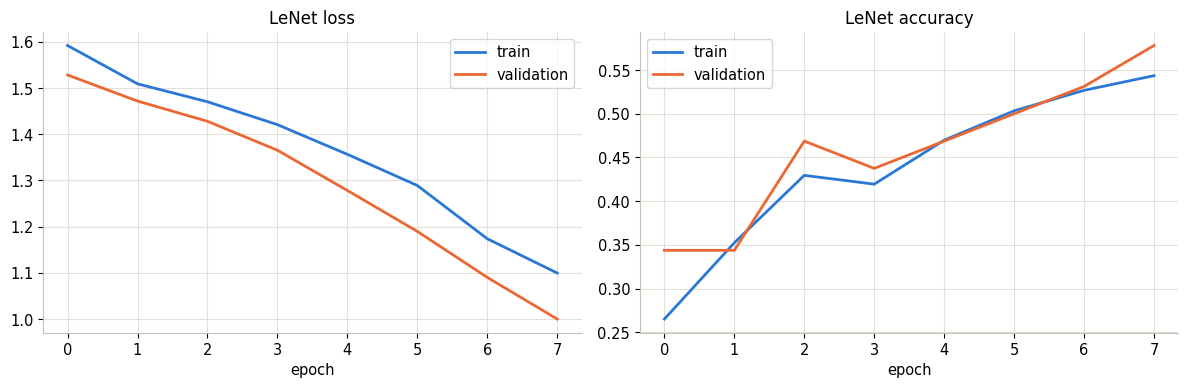

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, key, ttl in [(axes[0], "loss", "loss"), (axes[1], "acc", "accuracy")]:
    ax.plot(hist_lenet[f"train_{key}"], color=C["blue"], lw=2, label="train")
    ax.plot(hist_lenet[f"val_{key}"], color=C["orange"], lw=2, label="validation")
    ax.set(xlabel="epoch", title=f"LeNet {ttl}")
    ax.legend()
plt.tight_layout(); plt.show()

A 62-thousand-parameter network from 1998 already beats the majority baseline many
times over on 32×32 thumbnails of woven motifs. Also glance at the train/val gap —
Lab 3 taught you exactly how to read it.

## 7. AlexNet — your turn  *(~22 min)*

**AlexNet** (Krizhevsky, Sutskever & Hinton, 2012) is LeNet's design scaled up ~1000×
in parameters — and the network whose ImageNet victory ignited the deep-learning era.
Three ingredients were new at scale: **ReLU** activations (train deep nets fast),
**Dropout** in the classifier head (Lab 3's regularization theme — randomly zeroing
units during training), and **GPU training**. Sound familiar? It should: you already
own every concept. Now build it.

**The architecture, layer by layer** (torchvision's variant; input 3×224×224):

| # | Layer | out ch | kernel | stride | pad | output (C, H, W) |
|---|-------|--------|--------|--------|-----|------------------|
| 1 | Conv2d + ReLU | 64 | 11 | 4 | 2 | (64, 55, 55) |
| 2 | MaxPool2d | — | 3 | 2 | 0 | (64, 27, 27) |
| 3 | Conv2d + ReLU | 192 | 5 | 1 | 2 | (192, 27, 27) |
| 4 | MaxPool2d | — | 3 | 2 | 0 | (192, 13, 13) |
| 5 | Conv2d + ReLU | 384 | 3 | 1 | 1 | (384, 13, 13) |
| 6 | Conv2d + ReLU | 256 | 3 | 1 | 1 | (256, 13, 13) |
| 7 | Conv2d + ReLU | 256 | 3 | 1 | 1 | (256, 13, 13) |
| 8 | MaxPool2d | — | 3 | 2 | 0 | (256, 6, 6) |
| 9 | AdaptiveAvgPool2d((6,6)) | — | — | — | — | (256, 6, 6) |
| 10 | Flatten → Dropout(0.5) → Linear(9216→4096) + ReLU | | | | | (4096,) |
| 11 | Dropout(0.5) → Linear(4096→4096) + ReLU | | | | | (4096,) |
| 12 | Linear(4096→num_classes) | | | | | logits |

*(Check row 1 with the formula: (224 − 11 + 2·2)/4 + 1 = 55. Verify one or two more
by hand — that habit catches most architecture bugs before PyTorch does.)*

In [34]:
class AlexNet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        ### ===== TODO 5: the convolutional feature extractor ========= ###
        # Build nn.Sequential following table rows 1-8 EXACTLY.
        # Pattern from LeNet: Conv2d(...), nn.ReLU(), and MaxPool2d where
        # the table says so. Conv2d args: (in_ch, out_ch, kernel_size,
        # stride=..., padding=...). In-channels of each conv = out-channels
        # of the previous conv (start from 3 for RGB).
        self.features = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=64, kernel_size=11, stride=4, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=0),
            nn.Conv2d(in_channels=64, out_channels=192, kernel_size=5, stride=1, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=0),
            nn.Conv2d(in_channels=192, out_channels=384, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=384, out_channels=256, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=0),
        )
        ### ===== END TODO ============================================= ###

        self.avgpool = nn.AdaptiveAvgPool2d((6, 6))     # row 9 (given)

        ### ===== TODO 6a: the classifier head ======================== ###
        # Rows 10-12: Dropout(0.5) -> Linear(256*6*6, 4096) -> ReLU
        #          -> Dropout(0.5) -> Linear(4096, 4096)   -> ReLU
        #          -> Linear(4096, num_classes)
        self.classifier = nn.Sequential(
            nn.Dropout(0.5), nn.Linear(256*6*6, 4096), nn.ReLU(),
            nn.Dropout(0.5), nn.Linear(4096, 4096), nn.ReLU(),
            nn.Linear(4096, num_classes),
        )
        ### ===== END TODO ============================================= ###

    def forward(self, x):
        ### ===== TODO 6b: wire it together (4 lines) ================= ###
        # features -> avgpool -> flatten (start_dim=1, like LeNet) -> classifier
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, start_dim=1)
        x = self.classifier(x)
        return x
        ### ===== END TODO ============================================= ###

<details><summary><b>Hint — TODO 5/6</b></summary>

Copy LeNet's structure and follow the table. The first block is
`nn.Conv2d(3, 64, kernel_size=11, stride=4, padding=2), nn.ReLU(),
nn.MaxPool2d(kernel_size=3, stride=2)`. Convs 5–7 have no pooling between them.
Forward: `x = self.features(x)`, `x = self.avgpool(x)`,
`x = torch.flatten(x, 1)`, `return self.classifier(x)`.
</details>

In [35]:
# ---- Check TODO 5 + 6: AlexNet -----------------------------------------------------
alexnet = AlexNet(NUM_CLASSES).to(DEVICE)
out = alexnet(torch.zeros(2, 3, 224, 224).to(DEVICE))
assert out is not None, "forward returned None"
assert out.shape == (2, NUM_CLASSES), f"output shape {tuple(out.shape)}, expected (2, {NUM_CLASSES})"

n_params = sum(p.numel() for p in alexnet.parameters())
print(f"parameters: {n_params:,}")
assert 50e6 < n_params < 66e6, "parameter count is off - compare your layers with the table"

# trace the feature extractor against the table
x = torch.zeros(1, 3, 224, 224).to(DEVICE)
expected = [(64, 55, 55), (64, 27, 27), (192, 27, 27), (192, 13, 13),
            (384, 13, 13), (256, 13, 13), (256, 13, 13), (256, 6, 6)]
seen = []
for layer in alexnet.features:
    x = layer(x)
    if isinstance(layer, (nn.Conv2d, nn.MaxPool2d)):
        seen.append(tuple(x.shape[1:]))
        print(f"after {layer.__class__.__name__:<10s} {tuple(x.shape[1:])}")
assert seen == expected, "a layer's output does not match the table - check kernel/stride/padding"
print(f"\nPASSED: AlexNet matches the table "
      f"({n_params/1e6:.1f}M parameters vs LeNet's 0.06M - a ~1000x scale-up)")

parameters: 57,024,325
after Conv2d     (64, 55, 55)
after MaxPool2d  (64, 27, 27)
after Conv2d     (192, 27, 27)
after MaxPool2d  (192, 13, 13)
after Conv2d     (384, 13, 13)
after Conv2d     (256, 13, 13)
after Conv2d     (256, 13, 13)
after MaxPool2d  (256, 6, 6)

PASSED: AlexNet matches the table (57.0M parameters vs LeNet's 0.06M - a ~1000x scale-up)


In [37]:
print(ALEX_EPOCHS)

2


In [39]:
ALEX_EPOCHS = 50
ALEX_IMG = 224

train_loader224, val_loader224, test_loader224 = make_loaders(ALEX_IMG, batch=32)
t0 = time.time()
hist_alex = fit(alexnet, train_loader224, val_loader224, epochs=ALEX_EPOCHS, lr=1e-4)
print(f"\nAlexNet trained in {time.time()-t0:.0f}s "
      f"({'CPU fast-mode: expect modest accuracy - on a Colab GPU run 10+ epochs' if FAST_MODE else 'GPU'})")

epoch  1/50 | train loss 1.538 acc 27.2% | val loss 1.498 acc 34.4%
epoch  2/50 | train loss 1.480 acc 35.6% | val loss 1.439 acc 34.4%
epoch  3/50 | train loss 1.342 acc 35.9% | val loss 1.426 acc 35.9%
epoch  4/50 | train loss 1.342 acc 46.0% | val loss 1.238 acc 59.4%
epoch  5/50 | train loss 1.113 acc 58.4% | val loss 1.023 acc 62.5%
epoch  6/50 | train loss 0.958 acc 63.1% | val loss 0.876 acc 65.6%
epoch  7/50 | train loss 0.848 acc 66.8% | val loss 0.916 acc 59.4%
epoch  8/50 | train loss 0.874 acc 63.1% | val loss 0.857 acc 73.4%
epoch  9/50 | train loss 0.810 acc 69.1% | val loss 0.772 acc 65.6%
epoch 10/50 | train loss 0.680 acc 74.5% | val loss 0.592 acc 84.4%
epoch 11/50 | train loss 0.555 acc 80.9% | val loss 0.354 acc 85.9%
epoch 12/50 | train loss 0.418 acc 82.2% | val loss 0.363 acc 84.4%
epoch 13/50 | train loss 0.501 acc 82.2% | val loss 0.501 acc 78.1%
epoch 14/50 | train loss 0.488 acc 82.9% | val loss 0.382 acc 89.1%
epoch 15/50 | train loss 0.510 acc 82.6% | val l

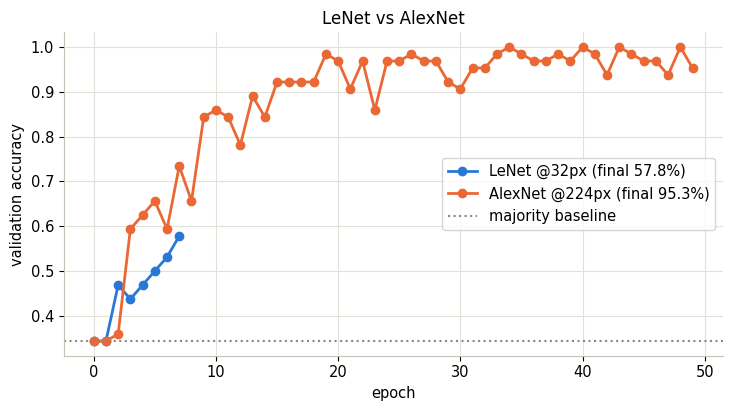

In [40]:
fig, ax = plt.subplots(figsize=(8.5, 4.2))
ax.plot(hist_lenet["val_acc"], "o-", color=C["blue"], lw=2,
        label=f"LeNet @32px (final {hist_lenet['val_acc'][-1]:.1%})")
ax.plot(hist_alex["val_acc"], "o-", color=C["orange"], lw=2,
        label=f"AlexNet @224px (final {hist_alex['val_acc'][-1]:.1%})")
ax.axhline(max(Counter(val_labels).values())/len(val_labels), color=C["muted"],
           ls=":", label="majority baseline")
ax.set(xlabel="epoch", ylabel="validation accuracy", title="LeNet vs AlexNet")
ax.legend()
plt.show()

**Reading the comparison honestly.** AlexNet has ~1000× the parameters, sees 7× the
resolution — and (especially in CPU fast-mode, or with few epochs) may still trail
LeNet at first: big models need more compute *and* more data to shine, and our capped
crop bank is small. That is not a failure — it is Lab 3's bias-variance lesson at
scale, and homework H2/H3 let you watch AlexNet overtake as data and epochs grow.

### 7.1 Where does the model still fail? *(given)*

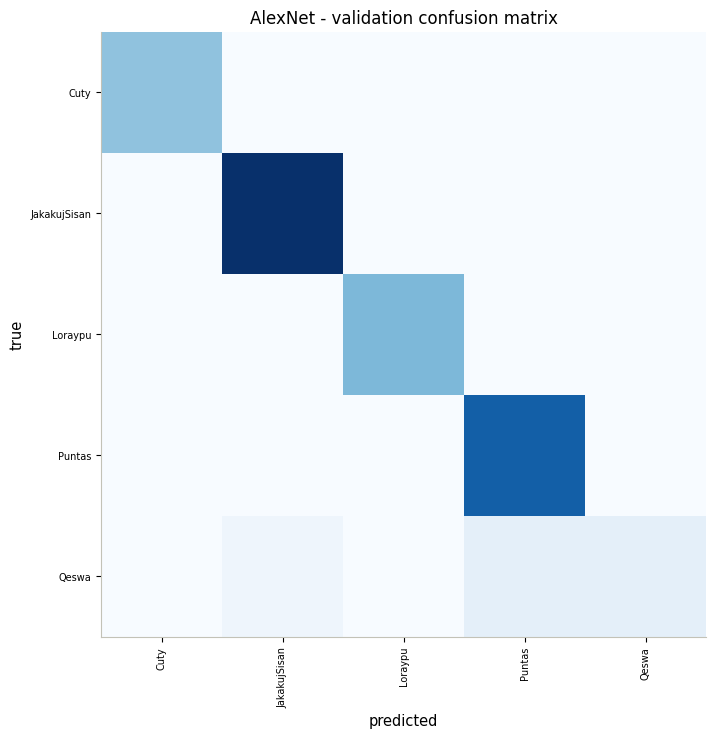

hardest classes: [('Qeswa', '40%'), ('Cuty', '100%'), ('Loraypu', '100%'), ('JakakujSisan', '100%'), ('Puntas', '100%')]


In [41]:
# Confusion matrix on the validation set (chosen model = whichever validated better)
best_model, best_loader, best_name = ((alexnet, val_loader224, "AlexNet")
    if hist_alex["val_acc"][-1] >= hist_lenet["val_acc"][-1]
    else (lenet, val_loader32, "LeNet"))

best_model.eval()
all_pred, all_true = [], []
with torch.no_grad():
    for xb, yb in best_loader:
        all_pred += best_model(xb.to(DEVICE)).argmax(1).cpu().tolist()
        all_true += list(yb)

cm = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=int)
for t, p in zip(all_true, all_pred): cm[t, p] += 1

fig, ax = plt.subplots(figsize=(8.5, 7.5))
ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(NUM_CLASSES), kept_classes, rotation=90, fontsize=7)
ax.set_yticks(range(NUM_CLASSES), kept_classes, fontsize=7)
ax.set(xlabel="predicted", ylabel="true",
       title=f"{best_name} - validation confusion matrix")
ax.grid(False)
plt.tight_layout(); plt.show()

per_class_acc = cm.diagonal() / np.maximum(cm.sum(axis=1), 1)
worst = np.argsort(per_class_acc)[:5]
print("hardest classes:", [(kept_classes[i], f"{per_class_acc[i]:.0%}") for i in worst])

## 8. Saving the model and running inference  *(~8 min)*

The artifact rule from Labs 1–3, CNN edition. What must ship together:

- the **weights** — `model.state_dict()` (the PyTorch convention: never pickle the
  whole model object, save its parameters);
- the **class names** (output index → motif name);
- the **preprocessing recipe** — image size, MEAN, STD. The transform IS the scaler:
  forget it at inference and you replay Lab 1/2's pitfall with pixels.

In [43]:
artifact = {
    "state_dict": {k: v.cpu() for k, v in best_model.state_dict().items()},
    "arch": best_name,
    "classes": kept_classes,
    "img_size": ALEX_IMG if best_name == "AlexNet" else 32,
    "mean": MEAN, "std": STD,
    "val_acc": (hist_alex if best_name == "AlexNet" else hist_lenet)["val_acc"][-1],
    "torch_version": torch.__version__,
}
save_model_path = "/content/drive/MyDrive/BrocadeAI/motif_classifier.pt"
torch.save(artifact, save_model_path)
print(f"saved motif_classifier.pt ({os.path.getsize(save_model_path)/1e6:.1f} MB)")

saved motif_classifier.pt (228.1 MB)


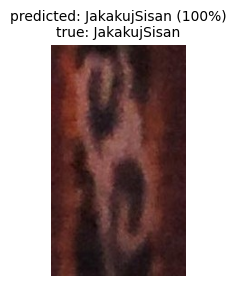

In [45]:
# --- INFERENCE (imagine: a fresh process) -------------------------------------------
art = torch.load(save_model_path, map_location="cpu", weights_only=False)
model = (AlexNet if art["arch"] == "AlexNet" else LeNet)(len(art["classes"]))
model.load_state_dict(art["state_dict"])
model.eval()                                     # <- crucial. see below.

infer_tf = transforms.Compose([
    transforms.Resize((art["img_size"], art["img_size"])),
    transforms.ToTensor(),
    transforms.Normalize(art["mean"], art["std"]),   # the SAVED stats
])

def predict_motif(path):
    x = infer_tf(Image.open(path).convert("RGB")).unsqueeze(0)   # add batch dim
    with torch.no_grad():
        probs = torch.softmax(model(x), dim=1)[0]
    top = probs.argmax().item()
    return art["classes"][top], probs[top].item()

f = test_files[0]
name, p = predict_motif(f)
fig, ax = plt.subplots(figsize=(3, 3))
ax.imshow(Image.open(f)); ax.axis("off")
ax.set_title(f"predicted: {name} ({p:.0%})\ntrue: {f.parent.name}", fontsize=10)
plt.show()

### 8.1 This lab's pitfall: forgetting `model.eval()`

Dropout randomly zeroes 50% of the classifier's units — *during training*. If you
forget to switch the model to eval mode, dropout stays on at inference, and the same
image gets a **different prediction every time you ask**. We demo on **AlexNet**,
whose head uses Dropout. (LeNet has no Dropout, so it happens to be immune — but
batch-norm, used by almost every modern network, misbehaves in train mode too, so the
rule is universal: *always* `model.eval()` before inference.)

In [46]:
tf224 = transforms.Compose([transforms.Resize((224, 224)), transforms.ToTensor(),
                            transforms.Normalize(MEAN, STD)])
x = tf224(Image.open(test_files[0]).convert("RGB")).unsqueeze(0).to(DEVICE)

alexnet.train()                                  # simulate the bug (dropout ON)
with torch.no_grad():
    p1 = torch.softmax(alexnet(x), 1)[0].max().item()
    p2 = torch.softmax(alexnet(x), 1)[0].max().item()
alexnet.eval()                                   # correct mode
with torch.no_grad():
    p3 = torch.softmax(alexnet(x), 1)[0].max().item()
    p4 = torch.softmax(alexnet(x), 1)[0].max().item()

print(f"train mode (BUG): same image twice -> {p1:.4f} vs {p2:.4f}   "
      f"({'DIFFERENT - the model is answering at random!' if p1 != p2 else 'same'})")
print(f"eval mode  (OK) : same image twice -> {p3:.4f} vs {p4:.4f}   "
      f"({'identical, as inference must be' if p3 == p4 else 'different?!'})")
assert p1 != p2 and p3 == p4, 'the demo should show train-mode randomness'


train mode (BUG): same image twice -> 1.0000 vs 1.0000   (DIFFERENT - the model is answering at random!)
eval mode  (OK) : same image twice -> 1.0000 vs 1.0000   (identical, as inference must be)


A model that answers differently every time it sees the same input is broken in the
quietest possible way — no error, plausible numbers, irreproducible results. The
series' pitfall collection now reads: *forgot the scaler* (Lab 1), *saturated
confidence* (Lab 2), *extrapolation* (Lab 3), **forgot `model.eval()`** (Lab 4). All
four share one moral: a model is its weights PLUS its preprocessing PLUS its mode.

## 9. Wrap-up  *(~2 min)*

What you built today, in pipeline order:

**YOLO labels parsed → boxes drawn & distributions read → detection Dataset + custom
collate + box-aware transforms → crop bank (detection → classification) →
classification Dataset + augmentation (train only!) → LeNet (read) → AlexNet (built) →
artifact with preprocessing + `model.eval()`**

Ideas worth remembering verbatim:

1. **EDA drives design**: imbalance → per-class caps and metrics; dense boxes → custom
   collate; small motifs on huge photos → the crop bank.
2. **A Dataset is two methods**; the DataLoader's default collate stacks tensors, so
   variable-length targets need your own `collate_fn`.
3. **Transforms are the scaler of vision**: Normalize stats learned on train only,
   shipped with the model; augmentation is regularization and belongs to train only.
4. **LeNet → AlexNet is the same idea scaled ~1000×** — conv/pool feature extractor
   plus a dense head; ReLU, Dropout and GPUs made the scale-up trainable.
5. **The output-size formula** `(in − K + 2P)/S + 1` plus a shape trace catches most
   CNN bugs before the first epoch.
6. **`model.eval()` at inference** — dropout must be off; predictions must be
   deterministic.

**The cliffhanger.** Your classifier recognizes a motif *when someone hands it a
crop*. But the crops came from human annotations! Detection — Lab 5 — is exactly the
question this lab left open: **who finds the boxes?** You already own most of the
answer: the backbone (today's CNN), the data plumbing (today's Dataset/collate), and
the discipline. Lab 5 adds IoU, the grid trick, and non-max suppression.

---

## Homework

**H1 — Augmentation ablation** *(Lab 3 meets Lab 4)*.
Train LeNet twice: once with the full train transform, once with augmentation removed
(use `eval_tf` for training too). Plot both val-accuracy curves and both train/val
gaps. Which regime overfits more? Explain in Lab 3's vocabulary.

**H2 — Feed the big model.** On Colab GPU, raise `MAX_PER_CLASS` to 400+, lower
`MIN_CROPS` to 20, and train AlexNet for 10–15 epochs. Report: does AlexNet now beat
LeNet? By how much? What happened to the rare classes' recall?

**H3 — Transfer learning teaser** *(the industry default)*.
`torchvision.models.alexnet(weights="IMAGENET1K_V1")` gives AlexNet pretrained on 1.2M
ImageNet photos. Replace its final Linear with one for our classes, train ONLY that
layer for 3 epochs (freeze the rest: `p.requires_grad = False`). Compare accuracy with
your from-scratch run — then explain why Lab 5 will happily reuse a pretrained
backbone.

---

## References and further reading

- Dataset: *Iconography of Chinchero* — annotated weaving-motif photographs
  (Data in Brief, 2026; distributed via Roboflow, CC BY 4.0). 1,358 images,
  28 classes, ~101k boxes.
- Y. LeCun et al., *Gradient-Based Learning Applied to Document Recognition* (1998) —
  LeNet-5.
- A. Krizhevsky, I. Sutskever, G. Hinton, *ImageNet Classification with Deep
  Convolutional Neural Networks* (NeurIPS 2012) — AlexNet.
- PyTorch docs: *Datasets & DataLoaders* tutorial; *torchvision.transforms.v2* (the
  box-aware transforms of Section 3.3); *TorchVision Object Detection Finetuning*.
- *Dive into Deep Learning* ch. 7 (ConvNets), ch. 8.1 (AlexNet), ch. 14.3–14.7
  (detection — Lab 5's reading).
- A. Ng, *Deep Learning Specialization* Course 4 — weeks 1–2 (ConvNets) match this
  lab; week 3 (Detection) matches Lab 5.